In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns

configurational library

In [120]:
import warnings
warnings.filterwarnings('ignore')

In [121]:
df = pd.read_csv('/content/covid_19_clean_complete.csv')

In [122]:
df.head(5)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


shape analysis


In [123]:
df.shape

(49068, 10)

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


we need to convert dat from object to int

In [125]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [126]:
df.duplicated().sum().sum()

np.int64(0)

In [127]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [128]:
df.rename(columns={'Province/State':'State','Country/Region':'Country'},inplace=True)

In [129]:
df.columns

Index(['State', 'Country', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths',
       'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [130]:
df.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [131]:
df.Date.value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


we can see that the max date is 7th of july

In [132]:
df.Date.min()

'2020-01-22'

In [133]:
df.Date.max()

'2020-07-27'

In [134]:
df[df['Date'] == '2020-01-22']

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
256,NaN,Sao Tome and Principe,0.186400,6.613100,2020-01-22,0,0,0,0,Africa
257,NaN,Yemen,15.552727,48.516388,2020-01-22,0,0,0,0,Eastern Mediterranean
258,NaN,Comoros,-11.645500,43.333300,2020-01-22,0,0,0,0,Africa
259,NaN,Tajikistan,38.861000,71.276100,2020-01-22,0,0,0,0,Europe


In [135]:
top = df[df['Date'] == '2020-07-27']
top.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.93911,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.15330,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.03390,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.50630,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.20270,17.873900,2020-07-27,950,41,242,667,Africa


**Grouping all rows based on Country**

In [136]:
top.groupby(by = 'Country')[['Confirmed', 'Deaths',
       'Recovered', 'Active']].sum().reset_index()

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667
...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791
183,Western Sahara,10,1,8,1
184,Yemen,1691,483,833,375
185,Zambia,4552,140,2815,1597


Let`s talk about conform cases

In [137]:
Confirmed = df.groupby(by = 'Date')['Confirmed'].sum().reset_index()

In [138]:
Confirmed.head()

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


In [139]:
Confirmed.tail()

,Date,Confirmed
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796
187,2020-07-27,16480485


In [140]:
df.Date.unique()

array(['2020-01-22', '2020-01-23', '2020-01-24', '2020-01-25',
       '2020-01-26', '2020-01-27', '2020-01-28', '2020-01-29',
       '2020-01-30', '2020-01-31', '2020-02-01', '2020-02-02',
       '2020-02-03', '2020-02-04', '2020-02-05', '2020-02-06',
       '2020-02-07', '2020-02-08', '2020-02-09', '2020-02-10',
       '2020-02-11', '2020-02-12', '2020-02-13', '2020-02-14',
       '2020-02-15', '2020-02-16', '2020-02-17', '2020-02-18',
       '2020-02-19', '2020-02-20', '2020-02-21', '2020-02-22',
       '2020-02-23', '2020-02-24', '2020-02-25', '2020-02-26',
       '2020-02-27', '2020-02-28', '2020-02-29', '2020-03-01',
       '2020-03-02', '2020-03-03', '2020-03-04', '2020-03-05',
       '2020-03-06', '2020-03-07', '2020-03-08', '2020-03-09',
       '2020-03-10', '2020-03-11', '2020-03-12', '2020-03-13',
       '2020-03-14', '2020-03-15', '2020-03-16', '2020-03-17',
       '2020-03-18', '2020-03-19', '2020-03-20', '2020-03-21',
       '2020-03-22', '2020-03-23', '2020-03-24', '2020-

Find the same for death, Active, and Recovered Cases

**Let's plot the graph to see how confirmed cases got increase**

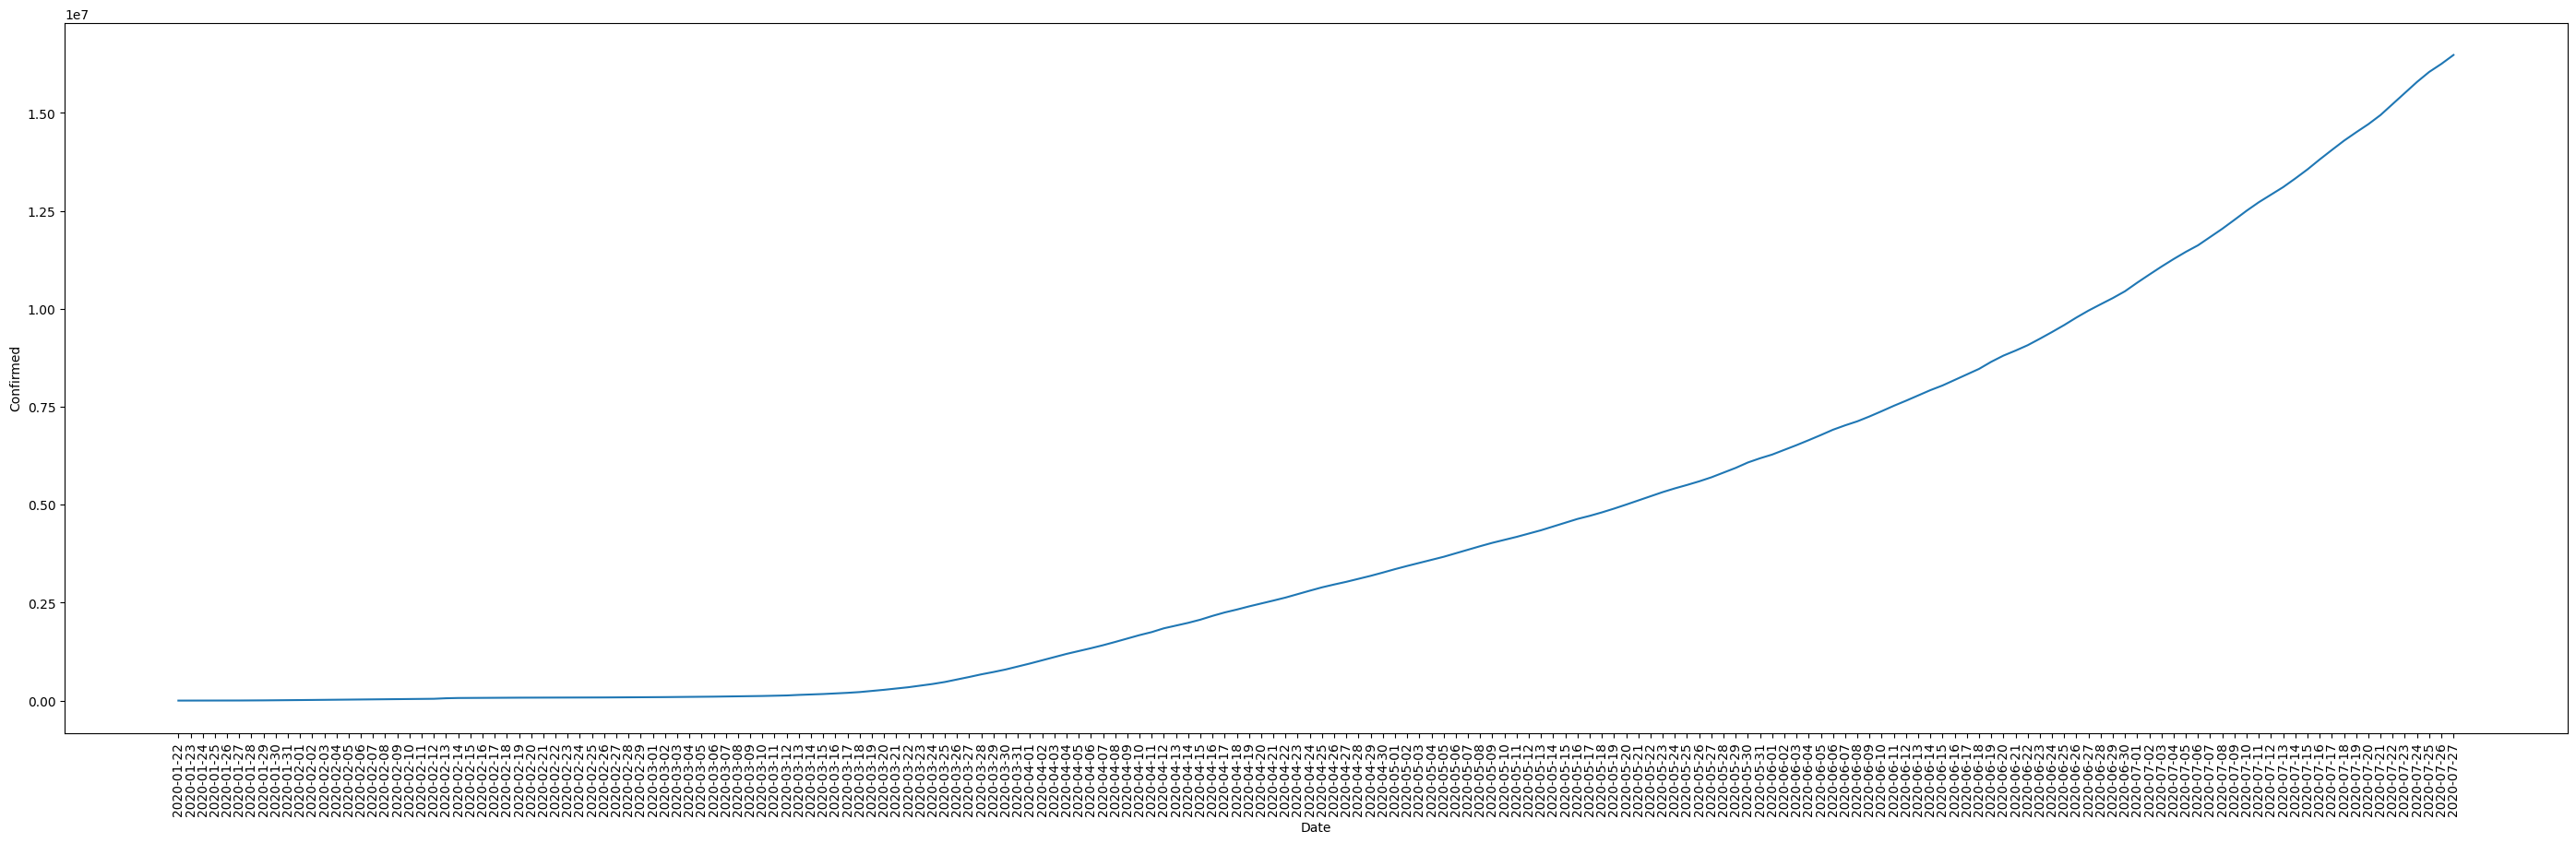

In [141]:
plt.figure(figsize= (35,10))
sns.lineplot(data=Confirmed,x ='Date',y='Confirmed')
plt.xticks(rotation = 90)
plt.show()

**TOP 10 COMPANY WITH MOST RECOVER CASES**

In [142]:
top_10_rec = df.groupby(by = 'Country')['Recovered'].sum().reset_index()

In [143]:
top_10_rec.head()

,Country,Recovered
0,Afghanistan,798240
1,Albania,118877
2,Algeria,755897
3,Andorra,69074
4,Angola,6573


In [144]:
top_10_rec.sort_values(by='Recovered', ascending=False,inplace=True)

In [145]:
top_10_rec.head(10)

,Country,Recovered
173,US,56353416
23,Brazil,54492873
138,Russia,25120448
79,India,23783720
65,Germany,17107839
85,Italy,15673910
81,Iran,15200895
157,Spain,15093583
172,Turkey,13345389
35,Chile,13292593


Can you find the same for Death, Confirmed and Active casestoo?

**Let's do for the active cases**

In [146]:
top_10_active = df.groupby(by='Country')['Active'].sum().sort_values(ascending=False).head(10).reset_index()

In [147]:
top_10_active

,Country,Active
0,US,156981121
1,Brazil,31094060
2,United Kingdom,22624595
3,Russia,19668578
4,India,15987913
5,France,10980287
6,Spain,9277432
7,Canada,8656985
8,Peru,7748957
9,Italy,7363518


**Let's Create the dataset specific for INDIA**

In [148]:
India = df[df['Country'] == 'India'].reset_index()
India.head()

,index,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,129,NaN,India,20.593684,78.96288,2020-01-22,0,0,0,0,South-East Asia
1,390,NaN,India,20.593684,78.96288,2020-01-23,0,0,0,0,South-East Asia
2,651,NaN,India,20.593684,78.96288,2020-01-24,0,0,0,0,South-East Asia
3,912,NaN,India,20.593684,78.96288,2020-01-25,0,0,0,0,South-East Asia
4,1173,NaN,India,20.593684,78.96288,2020-01-26,0,0,0,0,South-East Asia


In [149]:
India.tail()

,index,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
183,47892,NaN,India,20.593684,78.96288,2020-07-23,1288108,30601,817209,440298,South-East Asia
184,48153,NaN,India,20.593684,78.96288,2020-07-24,1337024,31358,849432,456234,South-East Asia
185,48414,NaN,India,20.593684,78.96288,2020-07-25,1385635,32060,885573,468002,South-East Asia
186,48675,NaN,India,20.593684,78.96288,2020-07-26,1435616,32771,917568,485277,South-East Asia
187,48936,NaN,India,20.593684,78.96288,2020-07-27,1480073,33408,951166,495499,South-East Asia


**Now.. For US**

In [150]:
US = df[df['Country'] == 'US']
US.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas


In [151]:
US.tail()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas
49030,NaN,US,40.0,-100.0,2020-07-27,4290259,148011,1325804,2816444,Americas


In [152]:
US.shape

(188, 10)

Let`s do for china

In [153]:
China = df[df['Country']== 'China']
China.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48,Anhui,China,31.8257,117.2264,2020-01-22,1,0,0,1,Western Pacific
49,Beijing,China,40.1824,116.4142,2020-01-22,14,0,0,14,Western Pacific
50,Chongqing,China,30.0572,107.8740,2020-01-22,6,0,0,6,Western Pacific
51,Fujian,China,26.0789,117.9874,2020-01-22,1,0,0,1,Western Pacific
52,Gansu,China,35.7518,104.2861,2020-01-22,0,0,0,0,Western Pacific


In [154]:
China.tail()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48883,Tianjin,China,39.3054,117.3230,2020-07-27,204,3,195,6,Western Pacific
48884,Tibet,China,31.6927,88.0924,2020-07-27,1,0,1,0,Western Pacific
48885,Xinjiang,China,41.1129,85.2401,2020-07-27,311,3,73,235,Western Pacific
48886,Yunnan,China,24.9740,101.4870,2020-07-27,190,2,186,2,Western Pacific
48887,Zhejiang,China,29.1832,120.0934,2020-07-27,1270,1,1268,1,Western Pacific


**Here, we are able to see China with very less total confirmend, death, active and recovered because we have states included**

In [155]:
df.columns

Index(['State', 'Country', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths',
       'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [156]:
China_State = China.groupby(by= 'State')[['Confirmed', 'Deaths',
       'Recovered', 'Active']].mean()
China_State

,Confirmed,Deaths,Recovered,Active
State,,,,
Anhui,917.537234,5.356383,828.553191,83.627660
Beijing,577.191489,7.356383,445.994681,123.840426
Chongqing,541.255319,5.388298,479.441489,56.425532
Fujian,318.377660,0.845745,281.574468,35.957447
Gansu,126.521277,1.813830,112.569149,12.138298
Guangdong,1425.803191,6.771277,1261.223404,157.808511
Guangxi,236.000000,1.787234,207.058511,27.154255
Guizhou,134.792553,1.781915,120.595745,12.414894
Hainan,157.361702,5.281915,137.925532,14.154255


In [157]:
China.groupby(by= 'Date')[['Confirmed', 'Deaths',
       'Recovered', 'Active']].sum()

,Confirmed,Deaths,Recovered,Active
Date,,,,
2020-01-22,548,17,28,503
2020-01-23,643,18,30,595
2020-01-24,920,26,36,858
2020-01-25,1406,42,39,1325
2020-01-26,2075,56,49,1970
...,...,...,...,...
2020-07-23,86045,4649,78701,2695
2020-07-24,86202,4650,78745,2807
2020-07-25,86381,4652,78813,2916


calculate the cases for 3-4 more countries and then compare the graph of those countries tpcheck how the cases were changed

**Top 10 Countries with Most Deaths**

In [158]:
top_10_deaths = df.groupby(by='Country')['Deaths'].sum().sort_values(ascending=False).head(10).reset_index()
display(top_10_deaths)

,Country,Deaths
0,US,11011411
1,United Kingdom,3997775
2,Brazil,3938034
3,Italy,3707717
4,France,3048524
5,Spain,3033030
6,Mexico,1728277
7,India,1111831
8,Iran,1024136
9,Belgium,963679


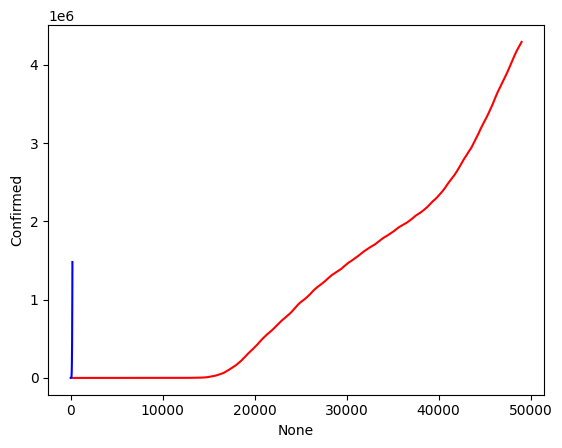

In [159]:
sns.lineplot(data = US, x =US.index, y=US.Confirmed, color = 'Red')
sns.lineplot(data = India, x =India.index, y=India.Confirmed, color = 'Blue')
plt.show()

In [160]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   State       14664 non-null  object        
 1   Country     49068 non-null  object        
 2   Lat         49068 non-null  float64       
 3   Long        49068 non-null  float64       
 4   Date        49068 non-null  datetime64[ns]
 5   Confirmed   49068 non-null  int64         
 6   Deaths      49068 non-null  int64         
 7   Recovered   49068 non-null  int64         
 8   Active      49068 non-null  int64         
 9   WHO Region  49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [161]:
top

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.939110,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.153300,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.033900,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.506300,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.202700,17.873900,2020-07-27,950,41,242,667,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [162]:
regionCase = top.groupby('WHO Region')[['Confirmed'	,'Deaths'	,'Recovered'	,'Active']].sum().reset_index()

In [163]:
regionCase

,WHO Region,Confirmed,Deaths,Recovered,Active
0,Africa,723207,12223,440645,270339
1,Americas,8839286,342732,4468616,4027938
2,Eastern Mediterranean,1490744,38339,1201400,251005
3,Europe,3299523,211144,1993723,1094656
4,South-East Asia,1835297,41349,1156933,637015
5,Western Pacific,292428,8249,206770,77409


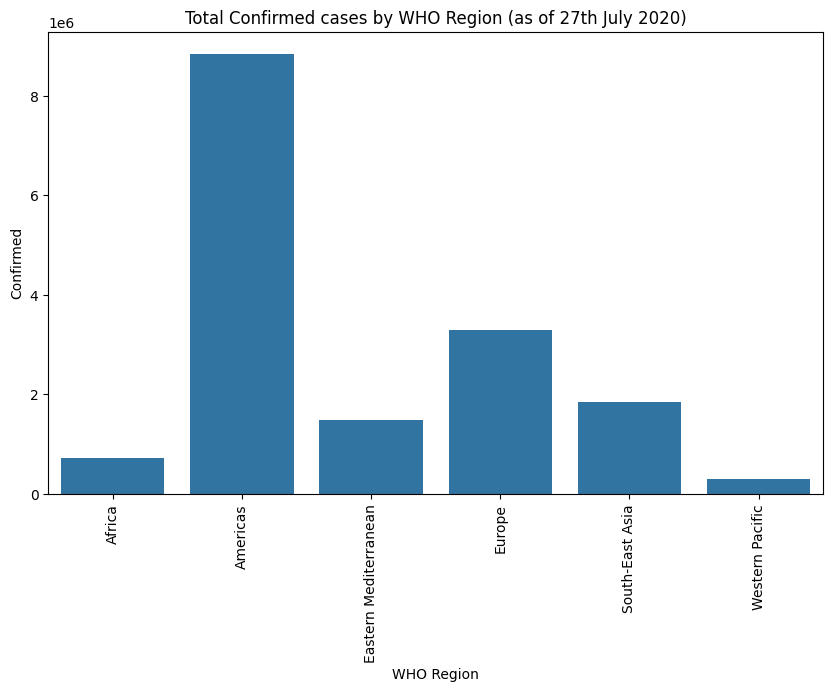

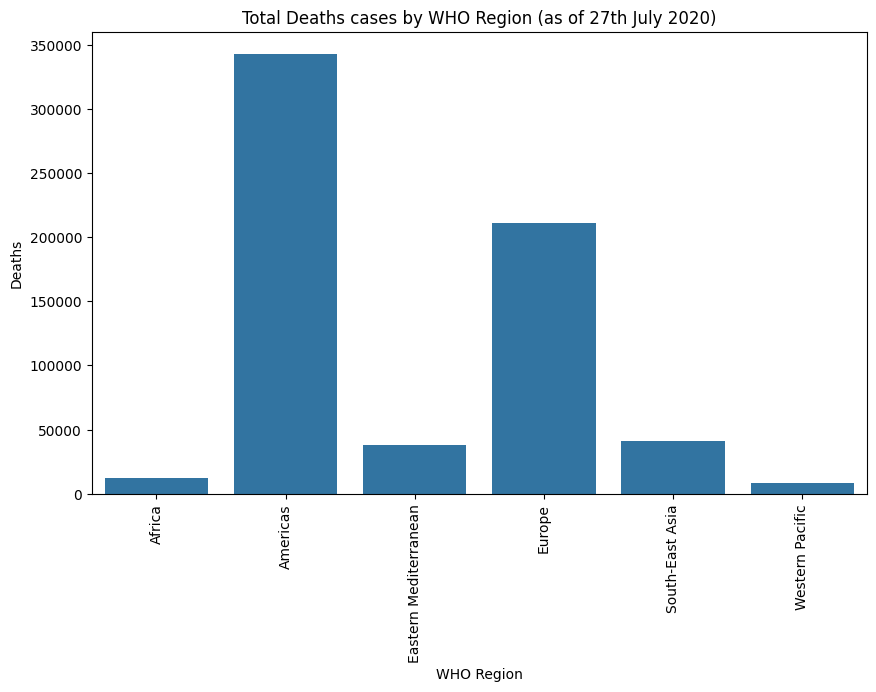

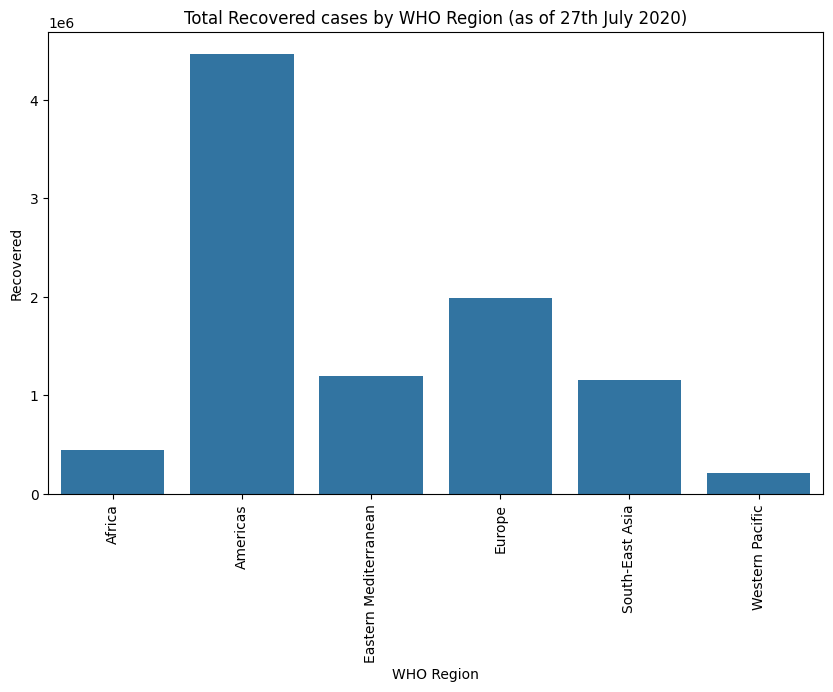

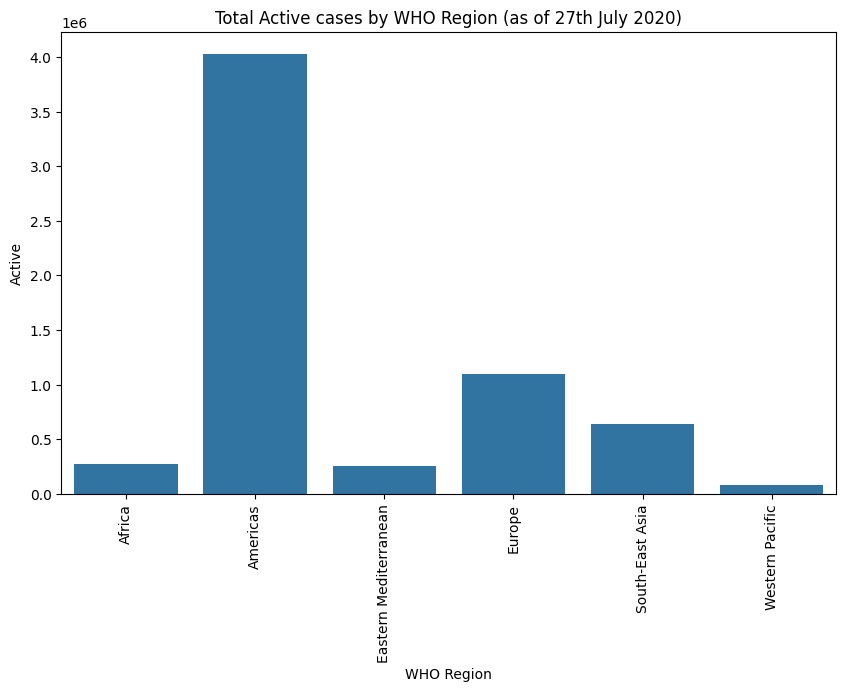

In [164]:
for col in ['Confirmed', 'Deaths', 'Recovered', 'Active']:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=regionCase, x='WHO Region', y=col)
    plt.title(f'Total {col} cases by WHO Region (as of 27th July 2020)')
    plt.xticks(rotation=90)
    plt.show()

In [165]:
df.columns

Index(['State', 'Country', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths',
       'Recovered', 'Active', 'WHO Region'],
      dtype='object')

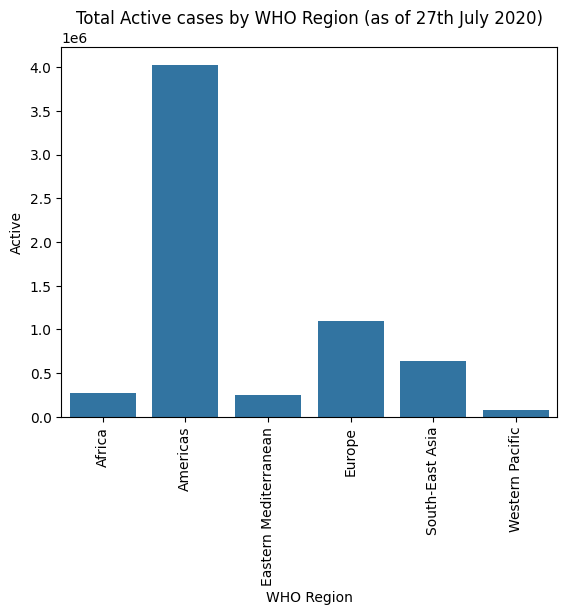

In [166]:
sns.barplot(data=regionCase, x = 'WHO Region', y='Active')
plt.title('Total Active cases by WHO Region (as of 27th July 2020)')
plt.xticks(rotation = 90)
plt.show()

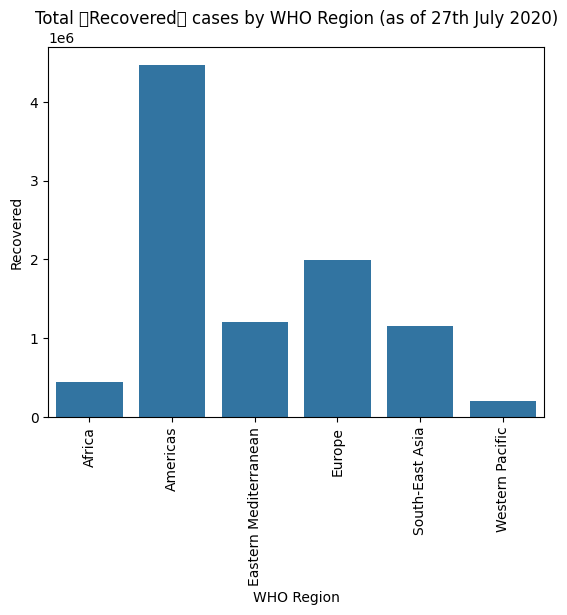

In [167]:
sns.barplot(data=regionCase, x = 'WHO Region', y='Recovered')
plt.title('Total 	Recovered	 cases by WHO Region (as of 27th July 2020)')
plt.xticks(rotation = 90)
plt.show()

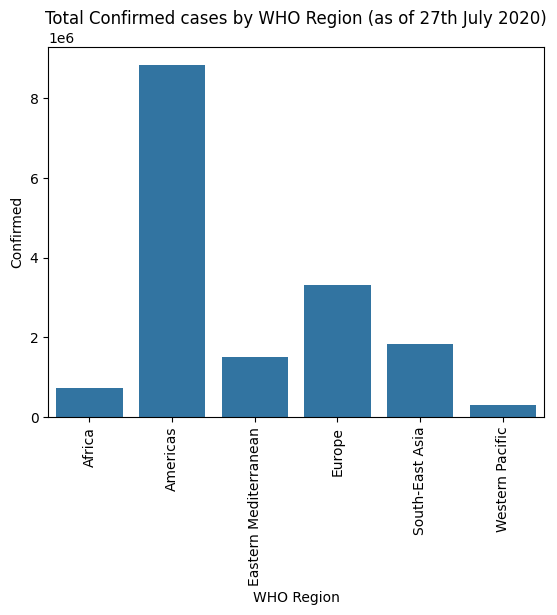

In [168]:
sns.barplot(data=regionCase, x = 'WHO Region', y='Confirmed')
plt.title('Total Confirmed cases by WHO Region (as of 27th July 2020)')
plt.xticks(rotation = 90)
plt.show()

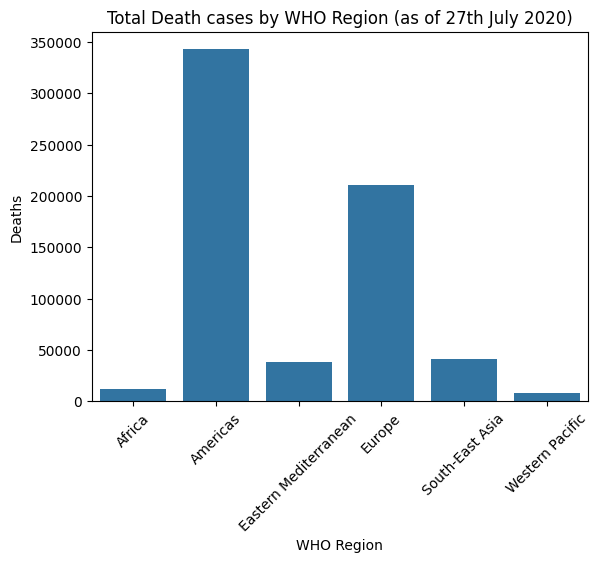

In [169]:
sns.barplot(data=regionCase, x = 'WHO Region', y='Deaths')
plt.title('Total Death cases by WHO Region (as of 27th July 2020)')
plt.xticks(rotation = 45)
plt.show()

**let`s find mortality and recovery rate**

In [170]:
WorldLatest = top.groupby(by='Country')[['Confirmed', 'Deaths',
       'Recovered']].sum().reset_index()

In [171]:
WorldLatest['Mortality Rate'] = WorldLatest['Deaths']/WorldLatest['Confirmed']

In [172]:
WorldLatest

,Country,Confirmed,Deaths,Recovered,Mortality Rate
0,Afghanistan,36263,1269,25198,0.034994
1,Albania,4880,144,2745,0.029508
2,Algeria,27973,1163,18837,0.041576
3,Andorra,907,52,803,0.057332
4,Angola,950,41,242,0.043158
...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,0.007344
183,Western Sahara,10,1,8,0.100000
184,Yemen,1691,483,833,0.285630
185,Zambia,4552,140,2815,0.030756


In [173]:
WorldLatest['Recovery Rate'] = (WorldLatest['Recovered']/WorldLatest['Confirmed'])*100
WorldLatest


,Country,Confirmed,Deaths,Recovered,Mortality Rate,Recovery Rate
0,Afghanistan,36263,1269,25198,0.034994,69.486805
1,Albania,4880,144,2745,0.029508,56.250000
2,Algeria,27973,1163,18837,0.041576,67.339935
3,Andorra,907,52,803,0.057332,88.533627
4,Angola,950,41,242,0.043158,25.473684
...,...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,0.007344,35.326240
183,Western Sahara,10,1,8,0.100000,80.000000
184,Yemen,1691,483,833,0.285630,49.260792
185,Zambia,4552,140,2815,0.030756,61.840949


**Let`s Sort values for Mortality and recovery rat in descending order**

In [174]:
WorldLatest.sort_values(by='Mortality Rate',ascending=False).head(10)

,Country,Confirmed,Deaths,Recovered,Mortality Rate,Recovery Rate
184,Yemen,1691,483,833,0.285630,49.260792
177,United Kingdom,301708,45844,1437,0.151948,0.476288
16,Belgium,66428,9822,17452,0.147859,26.272054
85,Italy,246286,35112,198593,0.142566,80.635115
61,France,220352,30212,81212,0.137108,36.855577
77,Hungary,4448,596,3329,0.133993,74.842626
120,Netherlands,53413,6160,189,0.115328,0.353846
111,Mexico,395489,44022,303810,0.111310,76.818824
157,Spain,272421,28432,150376,0.104368,55.199856
183,Western Sahara,10,1,8,0.100000,80.000000


**Model Building**

* we will be using meta Prophet model for performing time series forecasting

* it is developed by facebook back in 2017(now meta)

In [175]:
!pip install prophet

**I will forecast for Confirmed Cases**
* you guys need to do the forecasting for death case, recoer and active

###**Forecast**
Make sure to rename the date column as 'ds' and the target column as 'y'

In [177]:
Confirmed.columns = ['ds', 'y']
Confirmed.head(10)

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
5,2020-01-27,2927
6,2020-01-28,5578
7,2020-01-29,6166
8,2020-01-30,8234
9,2020-01-31,9927


In [178]:
from prophet import Prophet
m = Prophet()

**Now we will fit our data (both Data as well as Target)**
* Prophet model will give us future dataFrame upto certain time period

In [180]:
m.fit(Confirmed)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


**Making prediction for next 7 days**

In [182]:
 # Keyword for method -> make_future_dataframe() ---> Give the forecasted value
future = m.make_future_dataframe(periods = 7)
future

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [183]:
forecast = m.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.267820e+05,8.718578e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.148743e+05,8.932128e+04,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-9.885027e+04,1.108576e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-9.903481e+04,1.205804e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-1.023646e+05,1.106463e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.663960e+07,1.685099e+07,1.674098e+07,1.675120e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.684977e+07,1.706493e+07,1.693929e+07,1.696235e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.705543e+07,1.728792e+07,1.713501e+07,1.717396e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.725077e+07,1.748147e+07,1.732978e+07,1.738579e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07


In [185]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'weekly', 'weekly_lower', 'weekly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [186]:
forecast[['ds','yhat_lower','yhat_upper']]

,ds,yhat_lower,yhat_upper
0,2020-01-22,-1.267820e+05,8.718578e+04
1,2020-01-23,-1.148743e+05,8.932128e+04
2,2020-01-24,-9.885027e+04,1.108576e+05
3,2020-01-25,-9.903481e+04,1.205804e+05
4,2020-01-26,-1.023646e+05,1.106463e+05
...,...,...,...
190,2020-07-30,1.663960e+07,1.685099e+07
191,2020-07-31,1.684977e+07,1.706493e+07
192,2020-08-01,1.705543e+07,1.728792e+07
193,2020-08-02,1.725077e+07,1.748147e+07


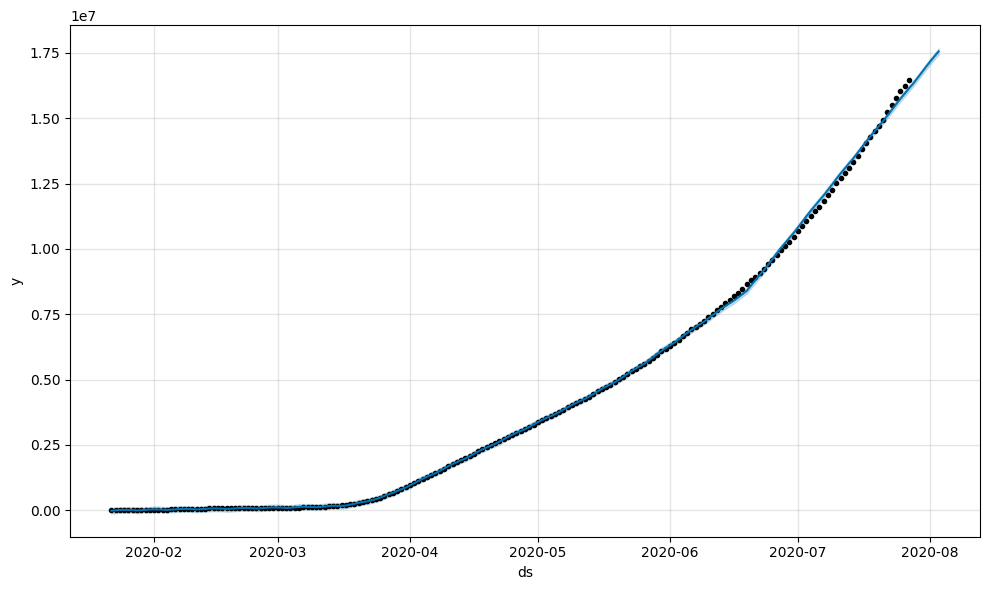

In [187]:
m.plot(forecast)
plt.show()

**Choropleth graph**

In [188]:
import plotly.express as px

In [189]:
top.columns

Index(['State', 'Country', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths',
       'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [190]:
world = top.groupby(by='Country')[['Confirmed', 'Deaths',
       'Recovered', 'Active']].sum().reset_index()

In [191]:
world

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667
...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791
183,Western Sahara,10,1,8,1
184,Yemen,1691,483,833,375
185,Zambia,4552,140,2815,1597


In [192]:
fig = px.choropleth(world,locations='Country',locationmode='country names',color='Deaths'
                        , hover_name='Country',color_continuous_scale='blues',
                    title='Countries with Death Cases')
fig.show()